In [ ]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

In [ ]:
df = pd.read_csv("luxury_cosmetics_fraud_analysis_2025.csv")

print(f"Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Time,Customer_Age,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Purchase_Amount,Payment_Method,Device_Type,IP_Address,Fraud_Flag,Footfall_Count
0,702bdd9b-9c93-41e3-9dbb-a849b2422080,119dca0b-8554-4b2d-9bec-e964eaf6af97,2025-07-27,04:04:15,56.0,Silver,San Francisco,FLAGSHIP-LA,NEBULA-SERUM-07,Concealer,158.24,Mobile Payment,Desktop,239.249.58.237,0,333
1,2e64c346-36bc-4acf-bc2b-8b0fdf46abc5,299df086-26c4-4708-b6d7-fcaeceb14637,2025-03-14,20:23:23,46.0,Platinum,Zurich,BOUTIQUE-SHANGHAI,STELLAR-FOUND-03,Lipstick,86.03,Credit Card,Tablet,84.49.227.90,0,406
2,29ad1278-70ce-421f-8d81-23816b39f4ac,dfa3d24d-b935-49a5-aa1d-7d57a44d8773,2025-02-20,12:36:02,32.0,Silver,Milan,POPUP-TOKYO,SOLAR-BLUSH-04,Mascara,255.69,Gift Card,Desktop,79.207.35.55,0,96
3,07dc4894-e0eb-48f1-99a7-1942b1973d9b,7a67e184-9369-49ee-aeac-18f5b51b230f,2025-04-25,19:09:43,60.0,Bronze,London,BOUTIQUE-NYC,GALAXIA-SET-08,Serum,282.76,Gift Card,Mobile,176.194.167.253,0,186
4,ae407054-5543-429c-918a-cdcc42ea9782,cf14730a-8f5a-453d-b527-39a278852b27,2025-04-17,14:23:23,NaN,Platinum,Miami,BOUTIQUE-NYC,LUNAR-MASC-02,Serum,205.86,Gift Card,Mobile,166.31.46.111,0,179


In [ ]:
# Display the number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Display the column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types and non null values
print("\nDataset Information:")
df.info()

# Display summary statistics for numerical features
print("\nSummary Statistics:")
display(df.describe())

# Display summary statistics for categorical features
print("\nCategorical Feature Summary:")
display(df.describe(include="object"))

Dataset Shape:
(2133, 16)

Column Names:
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Time', 'Customer_Age', 'Customer_Loyalty_Tier', 'Location', 'Store_ID', 'Product_SKU', 'Product_Category', 'Purchase_Amount', 'Payment_Method', 'Device_Type', 'IP_Address', 'Fraud_Flag', 'Footfall_Count']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2133 entries, 0 to 2132
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         2133 non-null   object 
 1   Customer_ID            2133 non-null   object 
 2   Transaction_Date       2133 non-null   object 
 3   Transaction_Time       2133 non-null   object 
 4   Customer_Age           2027 non-null   float64
 5   Customer_Loyalty_Tier  2027 non-null   object 
 6   Location               2133 non-null   object 
 7   Store_ID               2133 non-null   object 
 8   Product_SKU            2133 non-n

,Customer_Age,Purchase_Amount,Fraud_Flag,Footfall_Count
count,2027.000000,2133.000000,2133.000000,2133.000000
mean,41.684262,174.614074,0.030942,272.461791
std,13.718110,72.249043,0.173202,131.113027
min,18.000000,50.260000,0.000000,50.000000
25%,30.000000,113.850000,0.000000,157.000000
50%,42.000000,174.180000,0.000000,269.000000
75%,53.000000,236.360000,0.000000,388.000000
max,65.000000,299.910000,1.000000,500.000000



Categorical Feature Summary:


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Time,Customer_Loyalty_Tier,Location,Store_ID,Product_SKU,Product_Category,Payment_Method,Device_Type,IP_Address
count,2133,2133,2133,2133,2027,2133,2133,2133,2133,2027,2133,2133
unique,2133,2133,180,2106,5,20,10,10,10,4,4,2133
top,83108c8e-2ede-4e86-a0f6-ea4875c9e523,e94cecaf-9db8-49f4-97f6-a17bb5dd1187,2025-03-09,21:38:38,Bronze,Sydney,FLAGSHIP-PARIS,ECLIPSE-EYE-10,Serum,Debit Card,Tablet,249.251.176.173
freq,1,1,20,2,808,128,234,235,233,522,553,1


In [ ]:
# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values[missing_values > 0])

# Check for duplicate records
duplicate_count = df.duplicated().sum()

print(f"\nDuplicate Records: {duplicate_count}")

Missing Values:


,0
Customer_Age,106
Customer_Loyalty_Tier,106
Payment_Method,106



Duplicate Records: 0


In [ ]:
# Count the number of legitimate and fraudulent transactions
fraud_counts = df["Fraud_Flag"].value_counts().sort_index()

# Calculate the percentage distribution
fraud_percentages = df["Fraud_Flag"].value_counts(normalize=True).sort_index() * 100

# Create a summary table
fraud_summary = pd.DataFrame({
    "Count": fraud_counts,
    "Percentage": fraud_percentages.round(2)
})

fraud_summary.index = ["Legitimate", "Fraudulent"]

print("Fraud Class Distribution:")
display(fraud_summary)

Fraud Class Distribution:


,Count,Percentage
Legitimate,2067,96.91
Fraudulent,66,3.09


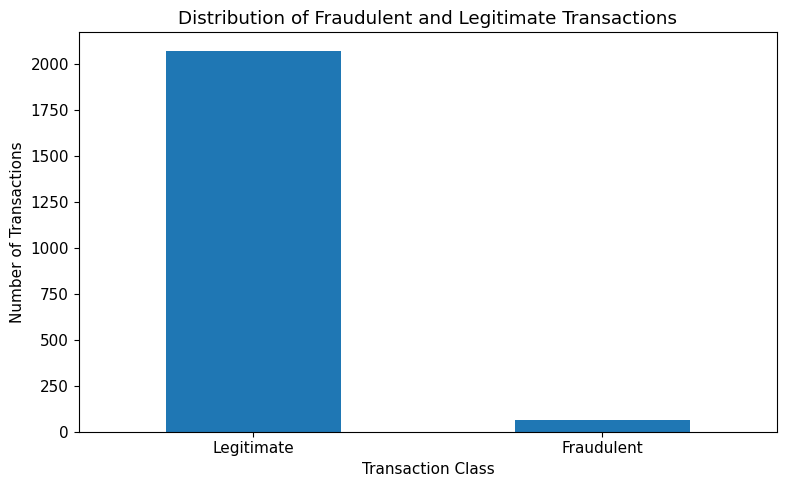

In [ ]:
# Plot the distribution of the target variable
fraud_counts.plot(
    kind="bar",
    xlabel="Transaction Class",
    ylabel="Number of Transactions",
    title="Distribution of Fraudulent and Legitimate Transactions",
    rot=0
)

plt.xticks([0, 1], ["Legitimate", "Fraudulent"])
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the class imbalance ratio
majority_class = fraud_counts.max()
minority_class = fraud_counts.min()

imbalance_ratio = majority_class / minority_class

print(f"Legitimate Transactions : {majority_class}")
print(f"Fraudulent Transactions : {minority_class}")
print(f"Fraud Rate              : {minority_class / len(df) * 100:.2f}%")
print(f"Class Imbalance Ratio   : {imbalance_ratio:.2f}:1")

Legitimate Transactions : 2067
Fraudulent Transactions : 66
Fraud Rate              : 3.09%
Class Imbalance Ratio   : 31.32:1


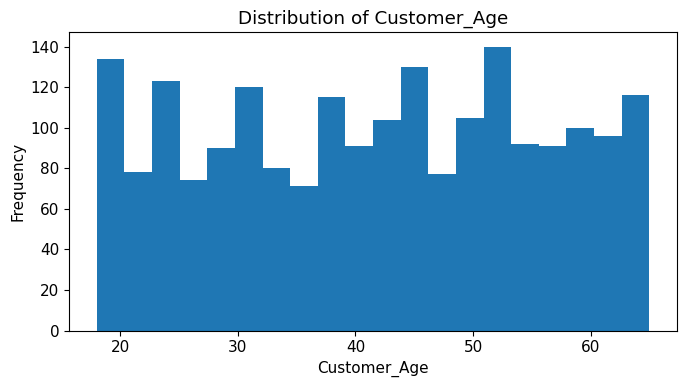

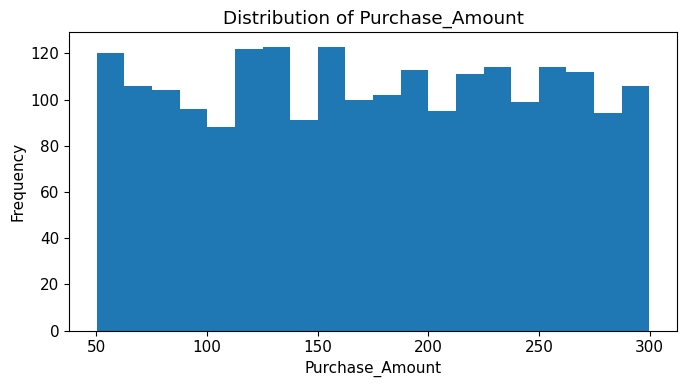

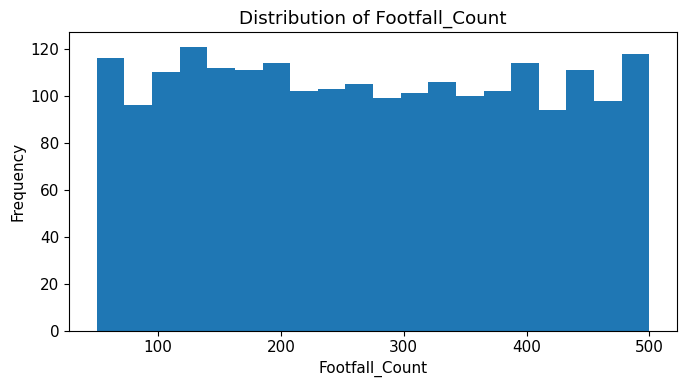

In [ ]:
# Select numerical features for visualization
numerical_features = [
    "Customer_Age",
    "Purchase_Amount",
    "Footfall_Count"
]

# Plot the distribution of each numerical feature
for feature in numerical_features:
    plt.figure(figsize=(7, 4))

    plt.hist(df[feature].dropna(), bins=20)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

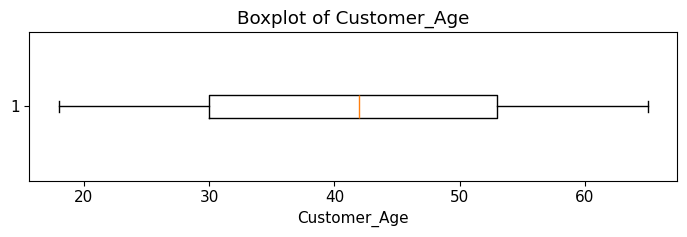

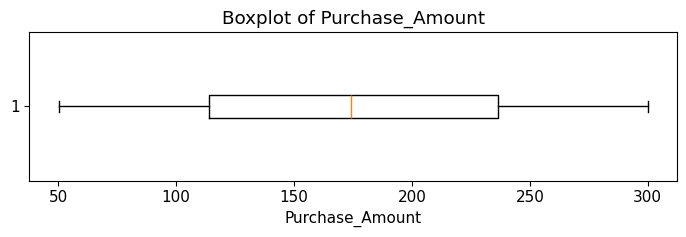

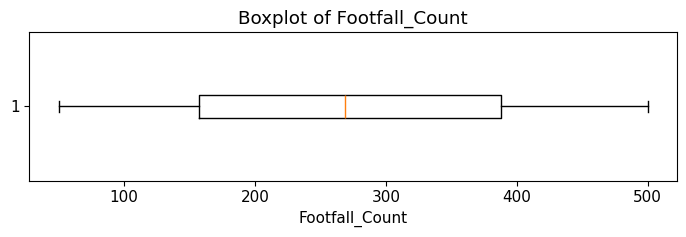

In [ ]:
# Visualize the spread and potential outliers of numerical features
for feature in numerical_features:
    plt.figure(figsize=(7, 2.5))

    plt.boxplot(df[feature].dropna(), vert=False)

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

In [ ]:
# Compare numerical features between legitimate and fraudulent transactions
fraud_comparison = df.groupby("Fraud_Flag")[
    ["Customer_Age", "Purchase_Amount", "Footfall_Count"]
].agg(["mean", "median", "std", "min", "max"])

display(fraud_comparison)

Customer_Age                               Purchase_Amount                                    Footfall_Count                            
                   mean median        std   min   max            mean   median        std    min     max           mean median         std min  max
Fraud_Flag                                                                                                                                         
0             41.665479   42.0  13.717461  18.0  65.0      174.865104  174.170  72.256163  50.26  299.91     271.966134  268.0  131.240112  50  500
1             42.269841   43.0  13.835679  19.0  64.0      166.752273  178.585  72.130203  50.27  295.23     287.984848  301.0  127.054621  55  489

In [ ]:
# Select categorical features for analysis
categorical_features = [
    "Customer_Loyalty_Tier",
    "Location",
    "Store_ID",
    "Product_Category",
    "Payment_Method",
    "Device_Type"
]

# Display the frequency of each category
for feature in categorical_features:
    print(f"\n{feature}")
    display(df[feature].value_counts(dropna=False))


Customer_Loyalty_Tier


,count
Customer_Loyalty_Tier,
Bronze,808
Silver,506
Gold,423
Platinum,179
VIP,111
NaN,106



Location


,count
Location,
Sydney,128
Zurich,121
Shanghai,117
Cannes,114
Hong Kong,114
Singapore,112
Monte Carlo,112
San Francisco,109
London,108



Store_ID


...

,count
Product_Category,
Serum,233
Highlighter,228
Blush,222
Mascara,219
Setting Spray,213
Lipstick,209
Eyeshadow Palette,209
Eyeliner,207
Concealer,199



Payment_Method


,count
Payment_Method,
Debit Card,522
Gift Card,514
Mobile Payment,500
Credit Card,491
NaN,106



Device_Type


,count
Device_Type,
Tablet,553
Desktop,536
Laptop,525
Mobile,519


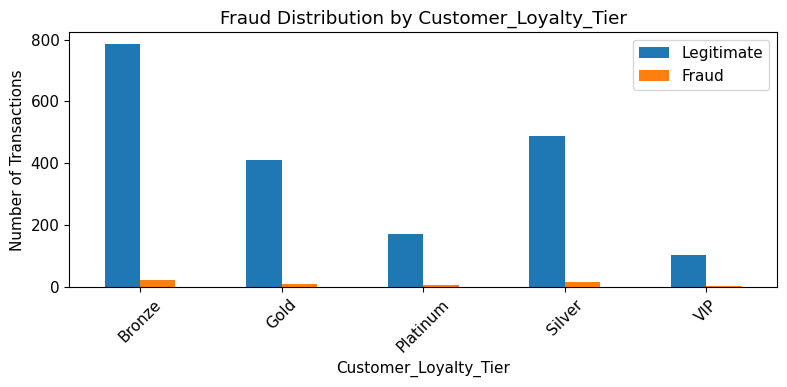

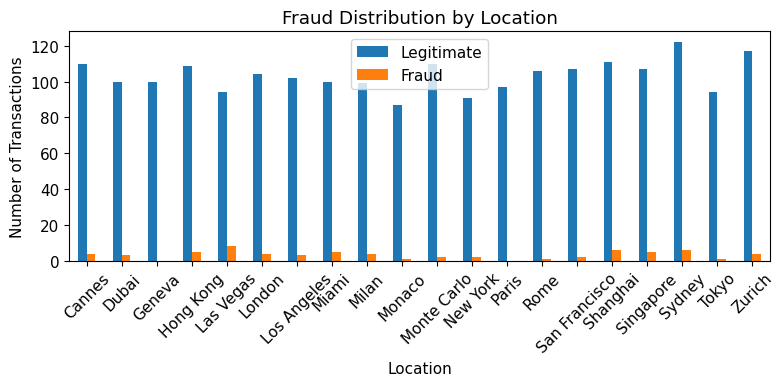

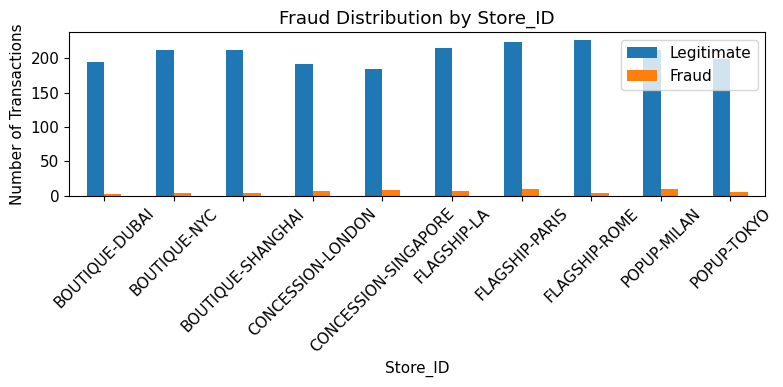

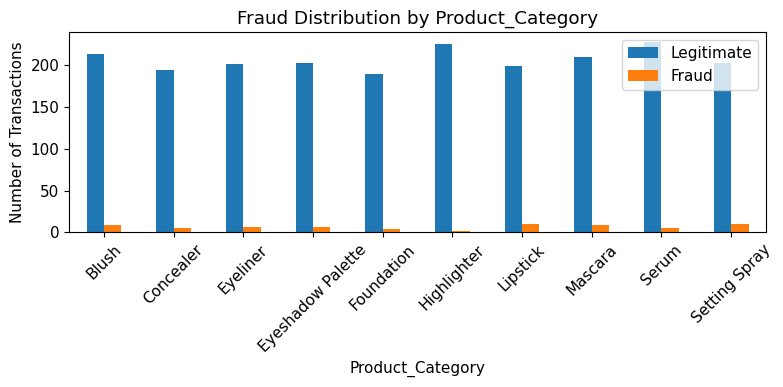

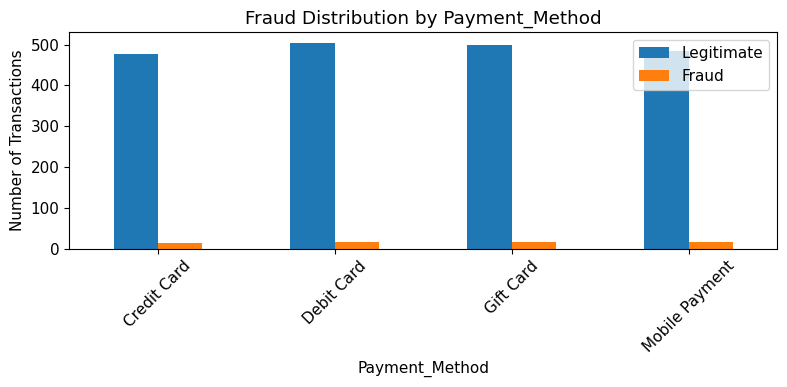

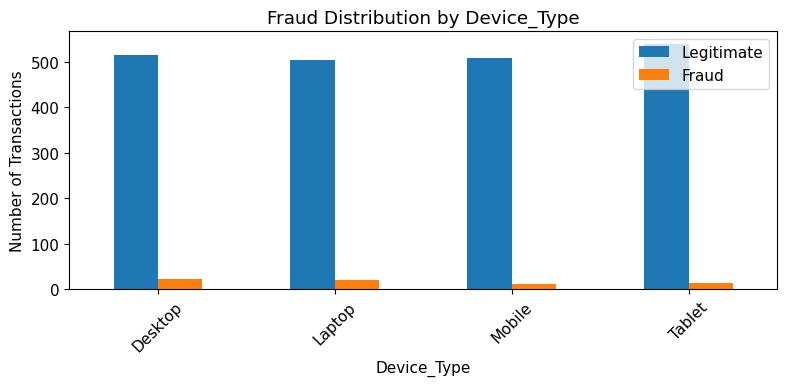

In [ ]:
# Visualize fraud distribution for each categorical feature
for feature in categorical_features:
    fraud_table = pd.crosstab(df[feature], df["Fraud_Flag"])

    fraud_table.plot(
        kind="bar",
        figsize=(8, 4),
        rot=45
    )

    plt.title(f"Fraud Distribution by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Transactions")

    plt.legend(["Legitimate", "Fraud"])

    plt.tight_layout()
    plt.show()

In [ ]:
# Calculate fraud percentage within each category
for feature in categorical_features:
    fraud_percentage = (
        pd.crosstab(df[feature], df["Fraud_Flag"], normalize="index") * 100
    ).round(2)

    print(f"\nFraud Percentage by {feature}")
    display(fraud_percentage)


Fraud Percentage by Customer_Loyalty_Tier


Fraud_Flag,0,1
Customer_Loyalty_Tier,,
Bronze,97.03,2.97
Gold,97.40,2.60
Platinum,96.09,3.91
Silver,96.84,3.16
VIP,94.59,5.41



Fraud Percentage by Location


Fraud_Flag,0,1
Location,,
Cannes,96.49,3.51
Dubai,97.09,2.91
Geneva,100.00,0.00
Hong Kong,95.61,4.39
Las Vegas,92.16,7.84
London,96.30,3.70
Los Angeles,97.14,2.86
Miami,95.24,4.76
Milan,96.12,3.88



Fraud Percentage by Store_ID


...

Fraud_Flag,0,1
Product_Category,,
Blush,95.95,4.05
Concealer,97.49,2.51
Eyeliner,97.10,2.90
Eyeshadow Palette,97.13,2.87
Foundation,97.94,2.06
Highlighter,99.12,0.88
Lipstick,95.22,4.78
Mascara,95.89,4.11
Serum,97.85,2.15



Fraud Percentage by Payment_Method


Fraud_Flag,0,1
Payment_Method,,
Credit Card,97.15,2.85
Debit Card,96.74,3.26
Gift Card,96.89,3.11
Mobile Payment,97.00,3.00



Fraud Percentage by Device_Type


Fraud_Flag,0,1
Device_Type,,
Desktop,95.90,4.10
Laptop,96.19,3.81
Mobile,97.88,2.12
Tablet,97.65,2.35


In [ ]:
# Convert transaction date to datetime format
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"])

# Convert transaction time to datetime format
df["Transaction_Time"] = pd.to_datetime(
    df["Transaction_Time"],
    format="%H:%M:%S"
)

# Extract useful temporal features
df["Transaction_Month"] = df["Transaction_Date"].dt.month_name()

df["Transaction_Day"] = df["Transaction_Date"].dt.day_name()

df["Transaction_Hour"] = df["Transaction_Time"].dt.hour

# Display the new features
df[
    [
        "Transaction_Date",
        "Transaction_Time",
        "Transaction_Month",
        "Transaction_Day",
        "Transaction_Hour"
    ]
].head()

,Transaction_Date,Transaction_Time,Transaction_Month,Transaction_Day,Transaction_Hour
0,2025-07-27,1900-01-01 04:04:15,July,Sunday,4
1,2025-03-14,1900-01-01 20:23:23,March,Friday,20
2,2025-02-20,1900-01-01 12:36:02,February,Thursday,12
3,2025-04-25,1900-01-01 19:09:43,April,Friday,19
4,2025-04-17,1900-01-01 14:23:23,April,Thursday,14


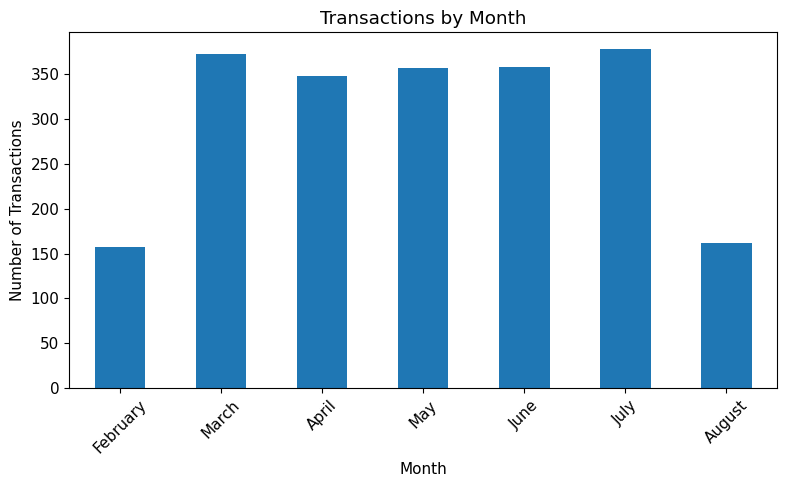

In [ ]:
# Count transactions by month
monthly_transactions = df["Transaction_Month"].value_counts()

# Reorder months chronologically
month_order = [
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August"
]

monthly_transactions = monthly_transactions.reindex(month_order)

# Plot monthly transactions
monthly_transactions.plot(
    kind="bar",
    xlabel="Month",
    ylabel="Number of Transactions",
    title="Transactions by Month",
    rot=45
)

plt.tight_layout()
plt.show()

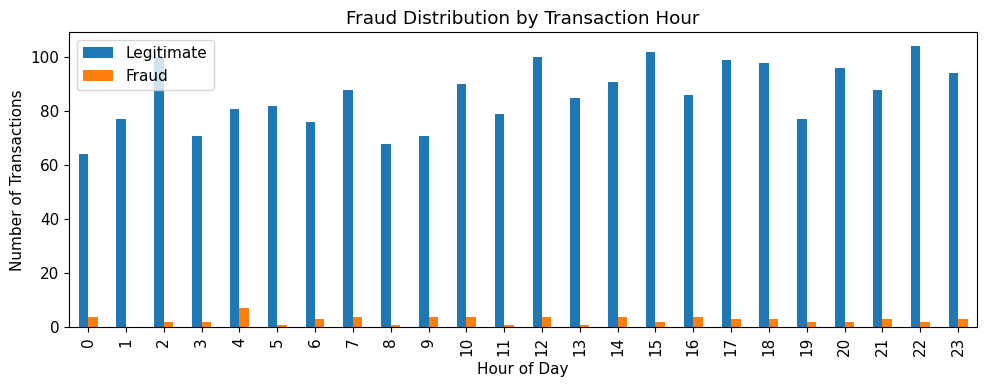

In [ ]:
# Calculate fraud count by transaction hour
hourly_fraud = pd.crosstab(
    df["Transaction_Hour"],
    df["Fraud_Flag"]
)

# Plot fraud distribution by hour
hourly_fraud.plot(
    kind="bar",
    figsize=(10, 4)
)

plt.title("Fraud Distribution by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.legend(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

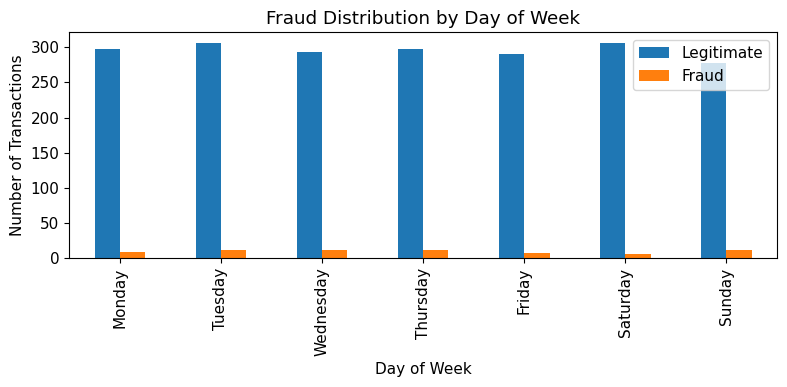

In [ ]:
# Arrange weekdays in chronological order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate fraud count by day
daily_fraud = pd.crosstab(
    df["Transaction_Day"],
    df["Fraud_Flag"]
)

daily_fraud = daily_fraud.reindex(day_order)

# Plot fraud distribution by day
daily_fraud.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Fraud Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")

plt.legend(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

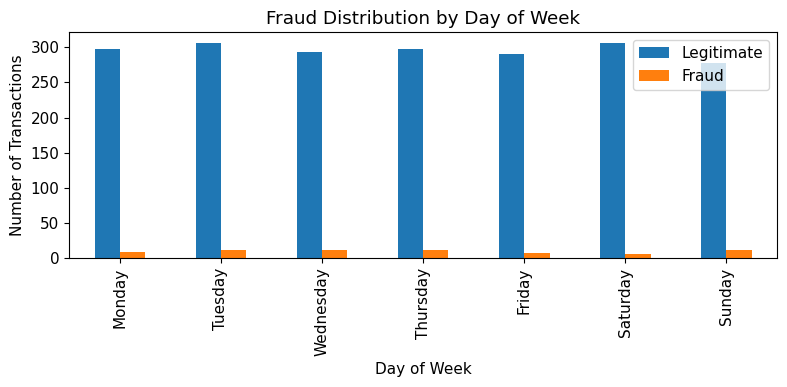

In [ ]:
# Arrange weekdays in chronological order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate fraud count by day
daily_fraud = pd.crosstab(
    df["Transaction_Day"],
    df["Fraud_Flag"]
)

daily_fraud = daily_fraud.reindex(day_order)

# Plot fraud distribution by day
daily_fraud.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Fraud Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")

plt.legend(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

In [ ]:
# Create a copy of the original dataset
data = df.copy()

# Display the dataset shape
print("Dataset Shape:", data.shape)

Dataset Shape: (2133, 19)


In [ ]:
# Fill missing values in Customer_Age using the median
data["Customer_Age"] = data["Customer_Age"].fillna(
    data["Customer_Age"].median()
)

# Fill missing values in Customer_Loyalty_Tier using the mode
data["Customer_Loyalty_Tier"] = data["Customer_Loyalty_Tier"].fillna(
    data["Customer_Loyalty_Tier"].mode()[0]
)

# Fill missing values in Payment_Method using the mode
data["Payment_Method"] = data["Payment_Method"].fillna(
    data["Payment_Method"].mode()[0]
)

# Verify that no missing values remain
print("Remaining Missing Values")
display(data.isnull().sum())

Remaining Missing Values


,0
Transaction_ID,0
Customer_ID,0
Transaction_Date,0
Transaction_Time,0
Customer_Age,0
Customer_Loyalty_Tier,0
Location,0
Store_ID,0
Product_SKU,0
Product_Category,0


In [ ]:
# Remove identifier columns
columns_to_drop = [
    "Transaction_ID",
    "Customer_ID",
    "IP_Address"
]

data = data.drop(columns=columns_to_drop)

# Display the remaining columns
print("Remaining Features")
display(data.columns)

Remaining Features


Index(['Transaction_Date', 'Transaction_Time', 'Customer_Age', 'Customer_Loyalty_Tier', 'Location', 'Store_ID', 'Product_SKU', 'Product_Category', 'Purchase_Amount', 'Payment_Method', 'Device_Type', 'Fraud_Flag', 'Footfall_Count', 'Transaction_Month', 'Transaction_Day', 'Transaction_Hour'], dtype='object')

In [ ]:
# Define the order of loyalty tiers
loyalty_order = {
    "Bronze": 0,
    "Silver": 1,
    "Gold": 2,
    "Platinum": 3,
    "VIP": 4
}

# Encode Customer_Loyalty_Tier
data["Customer_Loyalty_Tier"] = data["Customer_Loyalty_Tier"].map(loyalty_order)

# Display sample values
data[["Customer_Loyalty_Tier"]].head()

,Customer_Loyalty_Tier
0,1
1,3
2,1
3,0
4,3


In [ ]:
# Extract numerical features from the transaction date
data["Transaction_Month"] = data["Transaction_Date"].dt.month

data["Transaction_DayOfWeek"] = data["Transaction_Date"].dt.dayofweek

data["Transaction_DayOfMonth"] = data["Transaction_Date"].dt.day

# Display the new features
data[
    [
        "Transaction_Month",
        "Transaction_DayOfWeek",
        "Transaction_DayOfMonth",
        "Transaction_Hour"
    ]
].head()

,Transaction_Month,Transaction_DayOfWeek,Transaction_DayOfMonth,Transaction_Hour
0,7,6,27,4
1,3,4,14,20
2,2,3,20,12
3,4,4,25,19
4,4,3,17,14


In [ ]:
# Remove the original date and time columns
data = data.drop(
    columns=[
        "Transaction_Date",
        "Transaction_Time",
        "Transaction_Day",
        "Transaction_Month"
    ]
)

# Display the remaining columns
print("Remaining Features")
display(data.columns)

Remaining Features


Index(['Customer_Age', 'Customer_Loyalty_Tier', 'Location', 'Store_ID', 'Product_SKU', 'Product_Category', 'Purchase_Amount', 'Payment_Method', 'Device_Type', 'Fraud_Flag', 'Footfall_Count', 'Transaction_Hour', 'Transaction_DayOfWeek', 'Transaction_DayOfMonth'], dtype='object')

In [ ]:
# Select nominal categorical features
nominal_features = [
    "Location",
    "Store_ID",
    "Product_SKU",
    "Product_Category",
    "Payment_Method",
    "Device_Type"
]

# Apply one hot encoding
data = pd.get_dummies(
    data,
    columns=nominal_features,
    drop_first=True,
    dtype=int
)

# Display the first five rows
data.head()

,Customer_Age,Customer_Loyalty_Tier,Purchase_Amount,Fraud_Flag,Footfall_Count,Transaction_Hour,Transaction_DayOfWeek,Transaction_DayOfMonth,Location_Dubai,Location_Geneva,Location_Hong Kong,Location_Las Vegas,Location_London,Location_Los Angeles,Location_Miami,Location_Milan,Location_Monaco,Location_Monte Carlo,Location_New York,Location_Paris,Location_Rome,Location_San Francisco,Location_Shanghai,Location_Singapore,Location_Sydney,Location_Tokyo,Location_Zurich,Store_ID_BOUTIQUE-NYC,Store_ID_BOUTIQUE-SHANGHAI,Store_ID_CONCESSION-LONDON,Store_ID_CONCESSION-SINGAPORE,Store_ID_FLAGSHIP-LA,Store_ID_FLAGSHIP-PARIS,Store_ID_FLAGSHIP-ROME,Store_ID_POPUP-MILAN,Store_ID_POPUP-TOKYO,Product_SKU_CELESTE-EYE-05,Product_SKU_COSMIC-HIGHLIGHT-06,Product_SKU_ECLIPSE-EYE-10,Product_SKU_GALAXIA-SET-08,Product_SKU_LUNAR-MASC-02,Product_SKU_NEBULA-SERUM-07,Product_SKU_ORION-CONCEAL-09,Product_SKU_SOLAR-BLUSH-04,Product_SKU_STELLAR-FOUND-03,Product_Category_Concealer,Product_Category_Eyeliner,Product_Category_Eyeshadow Palette,Product_Category_Foundation,Product_Category_Highlighter,Product_Category_Lipstick,Product_Category_Mascara,Product_Category_Serum,Product_Category_Setting Spray,Payment_Method_Debit Card,Payment_Method_Gift Card,Payment_Method_Mobile Payment,Device_Type_Laptop,Device_Type_Mobile,Device_Type_Tablet
0,56.0,1,158.24,0,333,4,6,27,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,46.0,3,86.03,0,406,20,4,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
2,32.0,1,255.69,0,96,12,3,20,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
3,60.0,0,282.76,0,186,19,4,25,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0
4,42.0,3,205.86,0,179,14,3,17,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0


In [ ]:
# Display the final dataset shape
print("Final Dataset Shape")
print(data.shape)

# Check for missing values
print("\nRemaining Missing Values")
display(data.isnull().sum().sort_values(ascending=False).head())

# Display data types
print("\nData Types")
display(data.dtypes.value_counts())

Final Dataset Shape
(2133, 60)

Remaining Missing Values


,0
Customer_Age,0
Customer_Loyalty_Tier,0
Purchase_Amount,0
Fraud_Flag,0
Footfall_Count,0



Data Types


,count
int64,55
int32,3
float64,2


In [ ]:
# Separate the input features and target variable
X = data.drop(columns="Fraud_Flag")

y = data["Fraud_Flag"]

# Display the shape of features and target
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (2133, 59)
Target Shape: (2133,)


In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the dataset sizes
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (1706, 59)
Testing Set : (427, 59)


In [ ]:
# Display class distribution in the training set
train_distribution = y_train.value_counts().sort_index()

train_percentage = (
    y_train.value_counts(normalize=True).sort_index() * 100
).round(2)

train_summary = pd.DataFrame({
    "Count": train_distribution,
    "Percentage": train_percentage
})

train_summary.index = ["Legitimate", "Fraudulent"]

print("Training Set Class Distribution")
display(train_summary)

# Display class distribution in the testing set
test_distribution = y_test.value_counts().sort_index()

test_percentage = (
    y_test.value_counts(normalize=True).sort_index() * 100
).round(2)

test_summary = pd.DataFrame({
    "Count": test_distribution,
    "Percentage": test_percentage
})

test_summary.index = ["Legitimate", "Fraudulent"]

print("Testing Set Class Distribution")
display(test_summary)

Training Set Class Distribution


,Count,Percentage
Legitimate,1653,96.89
Fraudulent,53,3.11


Testing Set Class Distribution


,Count,Percentage
Legitimate,414,96.96
Fraudulent,13,3.04


In [ ]:
# Calculate the number of legitimate and fraudulent transactions
negative_class = (y_train == 0).sum()

positive_class = (y_train == 1).sum()

# Calculate the imbalance ratio
scale_pos_weight = negative_class / positive_class

print("Legitimate Transactions:", negative_class)
print("Fraudulent Transactions:", positive_class)
print(f"Scale Positive Weight: {scale_pos_weight:.2f}")

Legitimate Transactions: 1653
Fraudulent Transactions: 53
Scale Positive Weight: 31.19


In [ ]:
# Select numerical features for scaling
numerical_features = [
    "Customer_Age",
    "Purchase_Amount",
    "Footfall_Count",
    "Transaction_Hour",
    "Transaction_DayOfWeek",
    "Transaction_DayOfMonth"
]

# Create copies of the training and testing sets
X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

# Standardize the numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
# Define a function to evaluate classification models
def evaluate_model(model, X_test, y_test, feature_names=None):

    # Generate predictions
    y_pred = model.predict(X_test)

    # Generate prediction probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    # Display evaluation metrics
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(roc_auc, 4))
    print("PR AUC   :", round(pr_auc, 4))

    # Display confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)

    plt.title("Confusion Matrix")
    plt.colorbar()

    plt.xticks([0, 1], ["Legitimate", "Fraud"])
    plt.yticks([0, 1], ["Legitimate", "Fraud"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=12
            )

    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        label=f"ROC AUC = {roc_auc:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle=":"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")

    plt.legend()

    plt.tight_layout()
    plt.show()

    # Precision Recall Curve
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.figure(figsize=(6, 5))

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"PR AUC = {pr_auc:.3f}"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision Recall Curve")

    plt.legend()

    plt.tight_layout()
    plt.show()

    # Feature Importance for tree models
    if hasattr(model, "feature_importances_") and feature_names is not None:

        importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        })

        importance = importance.sort_values(
            by="Importance",
            ascending=False
        ).head(15)

        plt.figure(figsize=(8, 5))

        plt.barh(
            importance["Feature"],
            importance["Importance"]
        )

        plt.gca().invert_yaxis()

        plt.title("Top 15 Feature Importances")
        plt.xlabel("Importance")

        plt.tight_layout()
        plt.show()

    # Classification report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Return metrics
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc
    }

Baseline Logistic Regression Results

Accuracy : 0.9696
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5587
PR AUC   : 0.0379


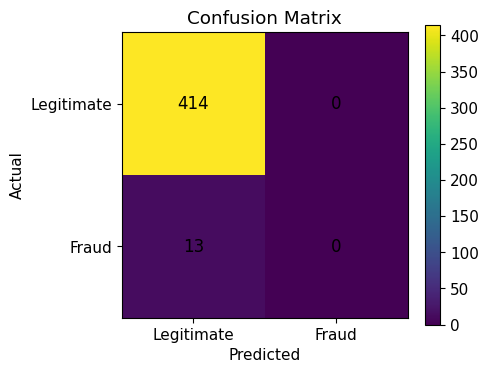

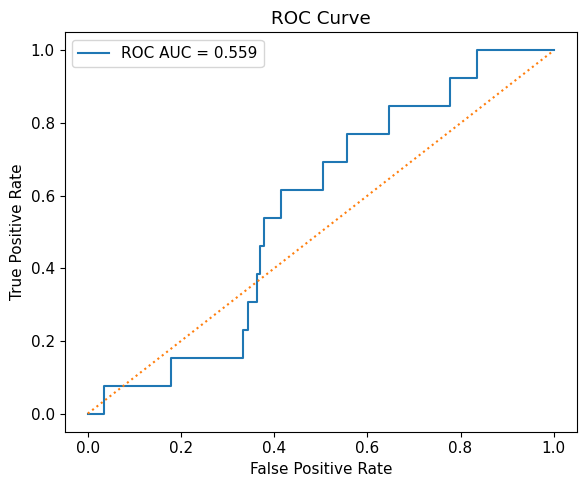

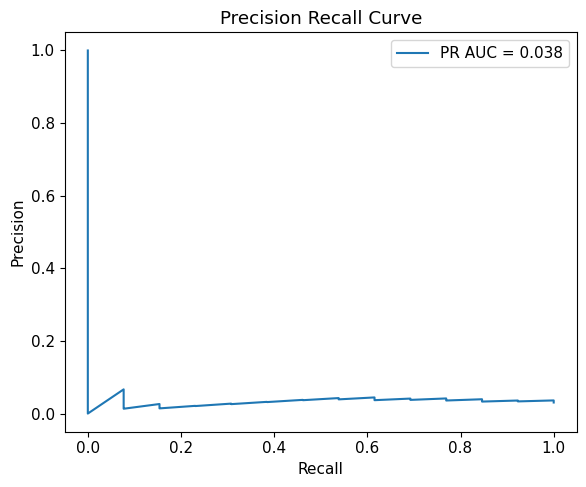


Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       414
           1       0.00      0.00      0.00        13

    accuracy                           0.97       427
   macro avg       0.48      0.50      0.49       427
weighted avg       0.94      0.97      0.95       427



In [ ]:
# Train the baseline Logistic Regression model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression Results\n")

logistic_results = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test
)

Baseline Decision Tree Results

Accuracy : 0.9297
Precision: 0.0526
Recall   : 0.0769
F1 Score : 0.0625
ROC AUC  : 0.5167
PR AUC   : 0.0322


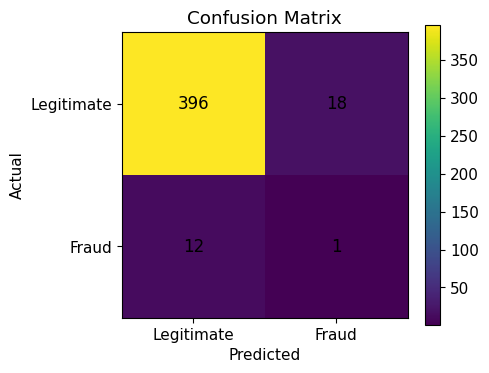

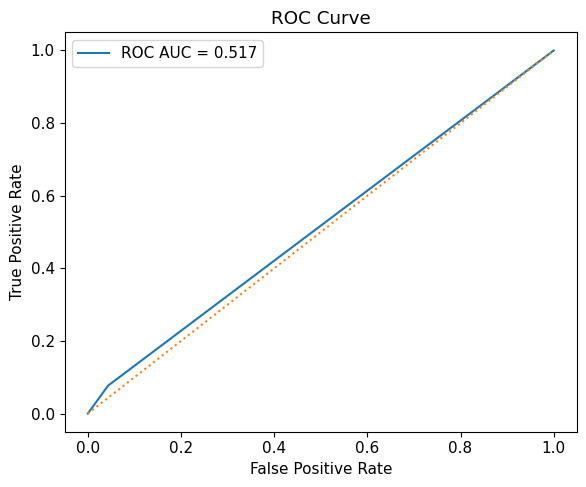

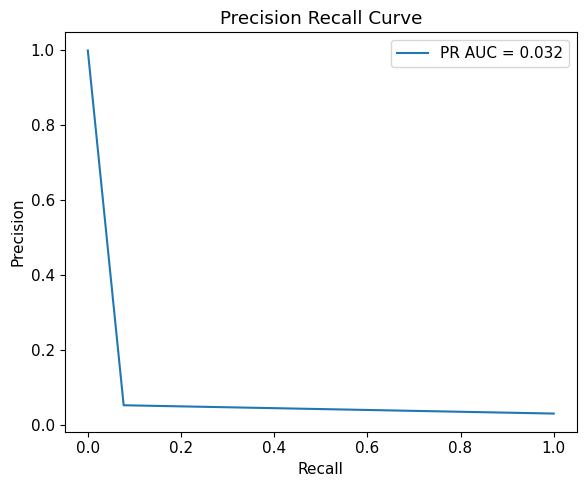


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       414
           1       0.05      0.08      0.06        13

    accuracy                           0.93       427
   macro avg       0.51      0.52      0.51       427
weighted avg       0.94      0.93      0.94       427



In [ ]:
# Train the baseline Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Baseline Decision Tree Results\n")

decision_tree_results = evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

In [ ]:
# Compare baseline model performance
baseline_results = pd.DataFrame(
    [
        logistic_results,
        decision_tree_results
    ],
    index=[
        "Logistic Regression",
        "Decision Tree"
    ]
)

baseline_results = baseline_results.round(4)

display(baseline_results)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Logistic Regression,0.9696,0.0000,0.0000,0.0000,0.5587,0.0379
Decision Tree,0.9297,0.0526,0.0769,0.0625,0.5167,0.0322


Cost Sensitive Logistic Regression Results

Accuracy : 0.6651
Precision: 0.0357
Recall   : 0.3846
F1 Score : 0.0654
ROC AUC  : 0.5985
PR AUC   : 0.0745


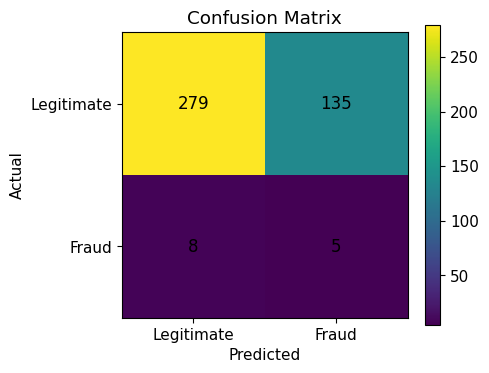

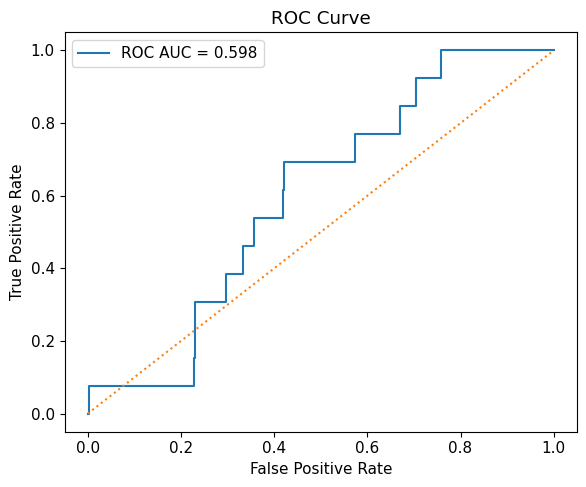

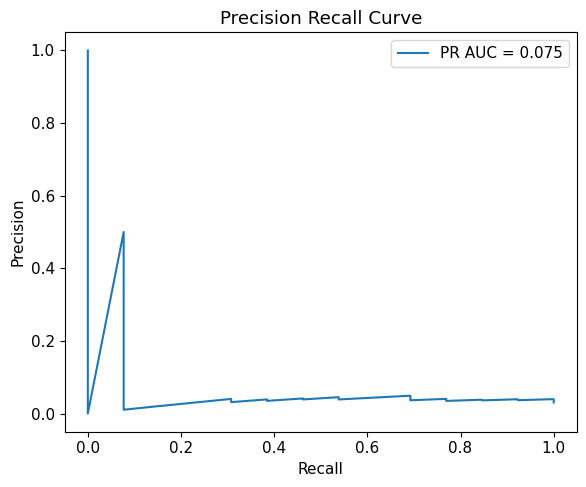


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.67      0.80       414
           1       0.04      0.38      0.07        13

    accuracy                           0.67       427
   macro avg       0.50      0.53      0.43       427
weighted avg       0.94      0.67      0.77       427



In [ ]:
# Train the cost sensitive Logistic Regression model
cost_logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

cost_logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Cost Sensitive Logistic Regression Results\n")

cost_logistic_results = evaluate_model(
    cost_logistic_model,
    X_test_scaled,
    y_test,
    X_train_scaled.columns
)

Cost Sensitive Random Forest Results

Accuracy : 0.9696
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5556
PR AUC   : 0.0366


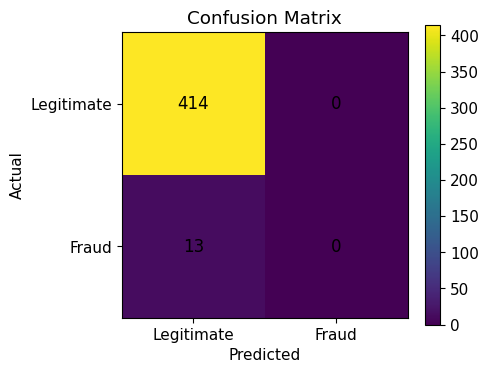

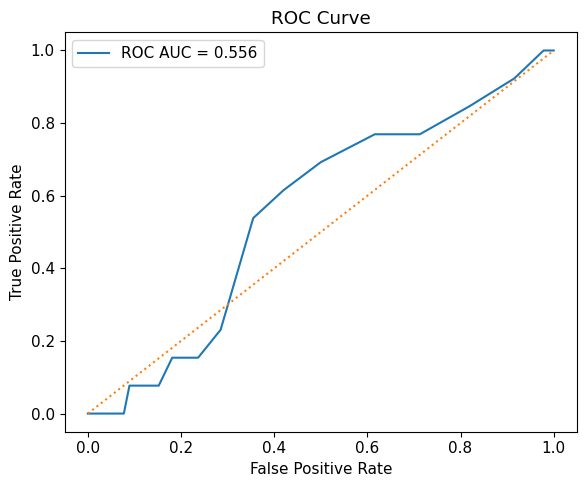

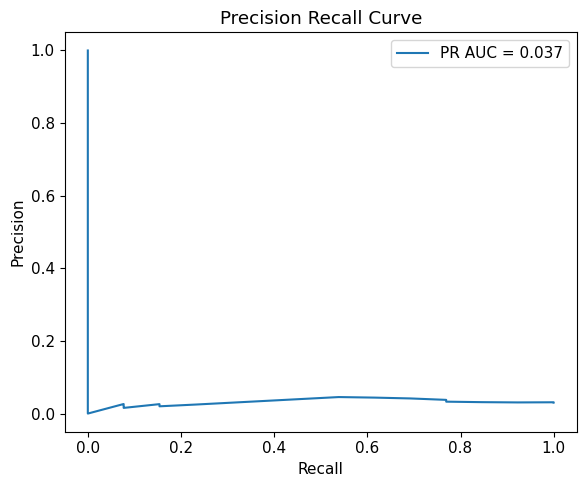

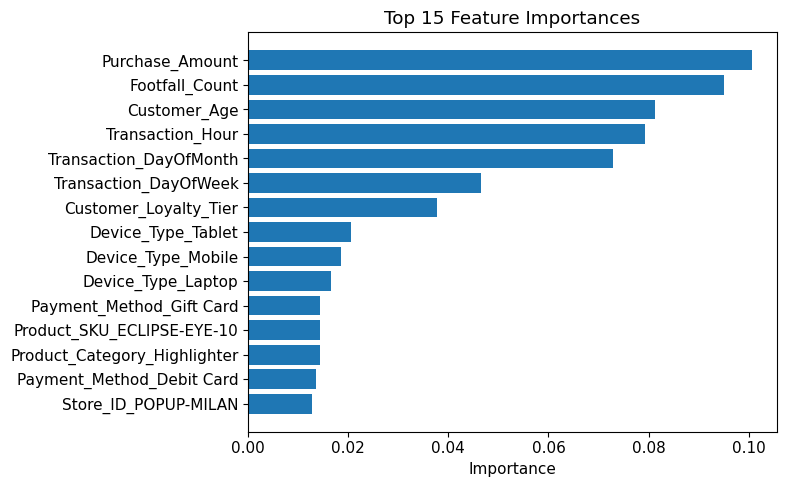


Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       414
           1       0.00      0.00      0.00        13

    accuracy                           0.97       427
   macro avg       0.48      0.50      0.49       427
weighted avg       0.94      0.97      0.95       427



In [ ]:
# Train the cost sensitive Random Forest model
cost_rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

cost_rf_model.fit(
    X_train,
    y_train
)

print("Cost Sensitive Random Forest Results\n")

cost_rf_results = evaluate_model(
    cost_rf_model,
    X_test,
    y_test,
    X_train.columns
)

Cost Sensitive XGBoost Results

Accuracy : 0.9508
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.502
PR AUC   : 0.0346


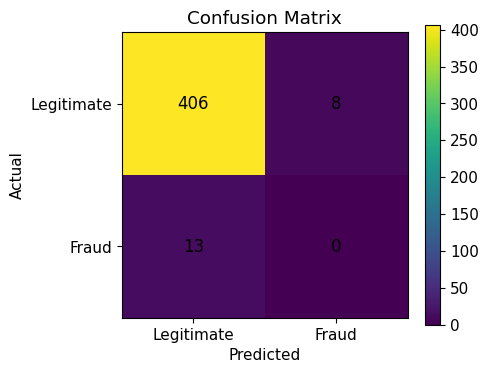

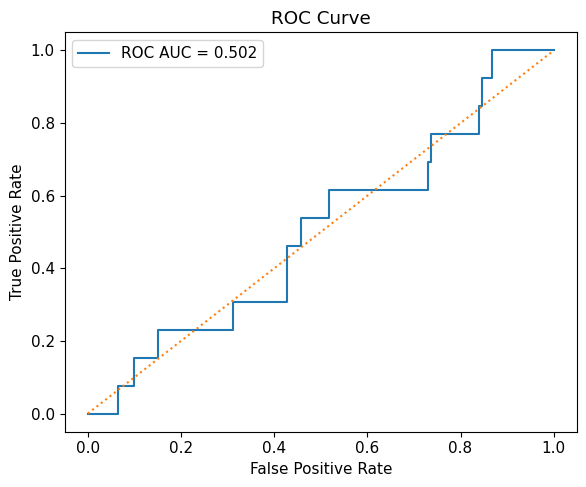

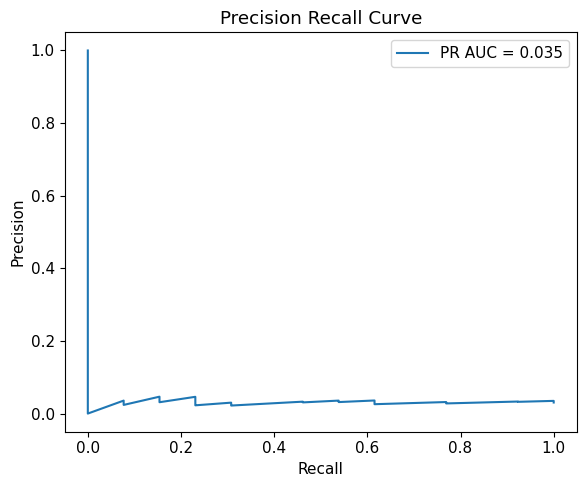

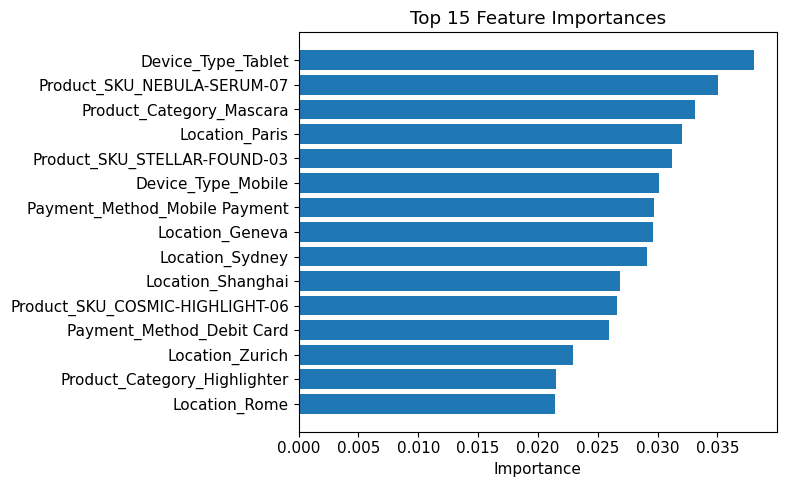


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       414
           1       0.00      0.00      0.00        13

    accuracy                           0.95       427
   macro avg       0.48      0.49      0.49       427
weighted avg       0.94      0.95      0.95       427



In [ ]:
# Train the cost sensitive XGBoost model
cost_xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

cost_xgb_model.fit(
    X_train,
    y_train
)

print("Cost Sensitive XGBoost Results\n")

cost_xgb_results = evaluate_model(
    cost_xgb_model,
    X_test,
    y_test,
    X_train.columns
)

Cost Sensitive LightGBM Results

Accuracy : 0.9485
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.4318
PR AUC   : 0.0279


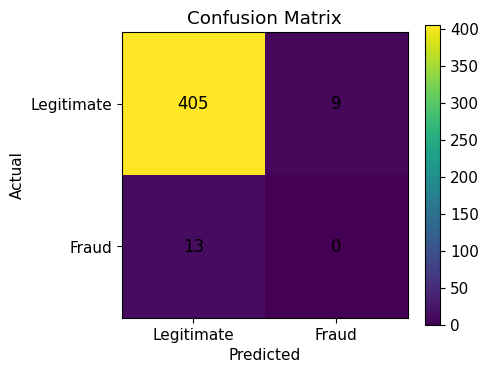

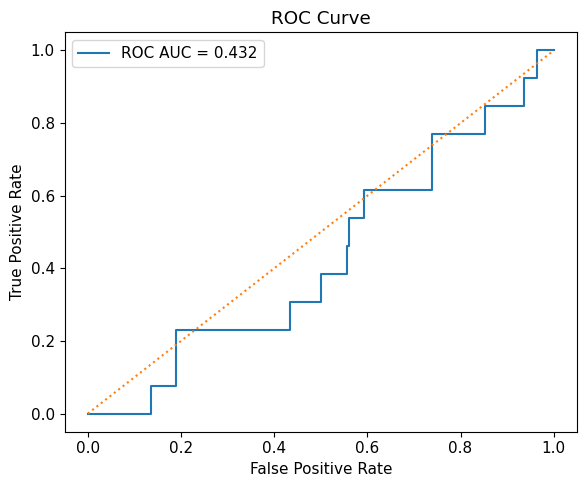

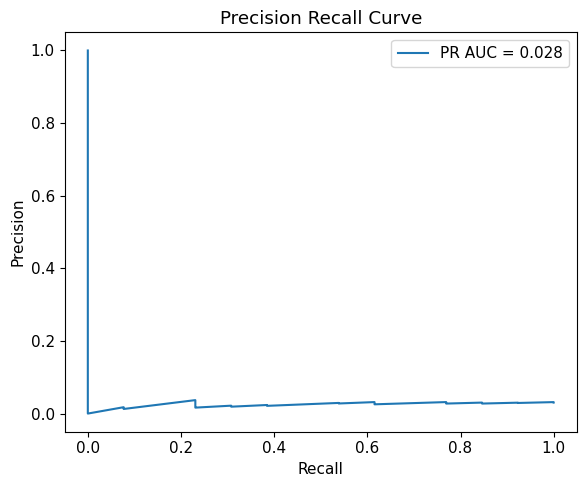

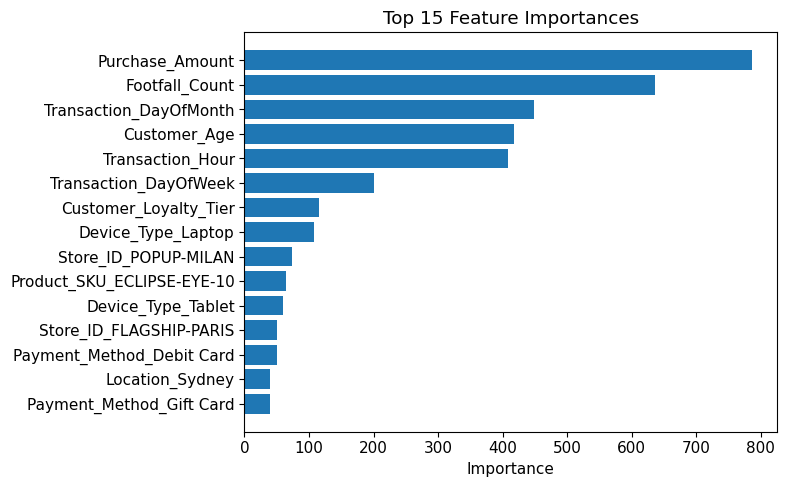


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       414
           1       0.00      0.00      0.00        13

    accuracy                           0.95       427
   macro avg       0.48      0.49      0.49       427
weighted avg       0.94      0.95      0.94       427



In [ ]:
# Train the cost sensitive LightGBM model
cost_lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

cost_lgbm_model.fit(
    X_train,
    y_train
)

print("Cost Sensitive LightGBM Results\n")

cost_lgbm_results = evaluate_model(
    cost_lgbm_model,
    X_test,
    y_test,
    X_train.columns
)

In [ ]:
# Compare all models
results = pd.DataFrame(
    [
        logistic_results,
        decision_tree_results,
        cost_logistic_results,
        cost_rf_results,
        cost_xgb_results,
        cost_lgbm_results
    ],
    index=[
        "Baseline Logistic Regression",
        "Baseline Decision Tree",
        "Cost Logistic Regression",
        "Cost Random Forest",
        "Cost XGBoost",
        "Cost LightGBM"
    ]
)

results = results.round(4)

display(results)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Baseline Logistic Regression,0.9696,0.0000,0.0000,0.0000,0.5587,0.0379
Baseline Decision Tree,0.9297,0.0526,0.0769,0.0625,0.5167,0.0322
Cost Logistic Regression,0.6651,0.0357,0.3846,0.0654,0.5985,0.0745
Cost Random Forest,0.9696,0.0000,0.0000,0.0000,0.5556,0.0366
Cost XGBoost,0.9508,0.0000,0.0000,0.0000,0.5020,0.0346
Cost LightGBM,0.9485,0.0000,0.0000,0.0000,0.4318,0.0279


In [ ]:
# Import hyperparameter tuning tools
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Define the Random Forest parameter grid
rf_parameters = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Create the Random Forest model
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

# Perform randomized search
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_parameters,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

# Display the best parameters
print("Best Random Forest Parameters")
print(rf_search.best_params_)

Best Random Forest Parameters
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}


Tuned Random Forest Results

Accuracy : 0.9532
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.4554
PR AUC   : 0.0291


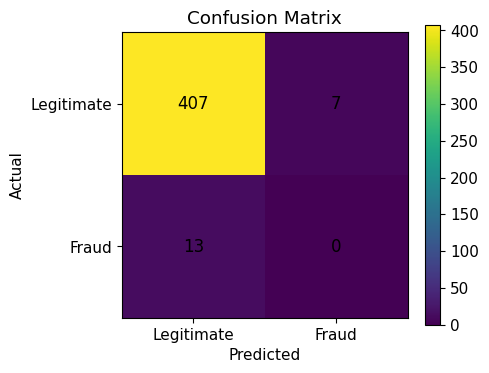

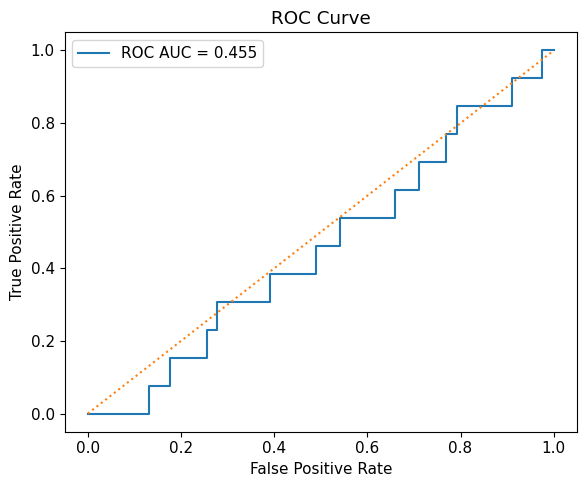

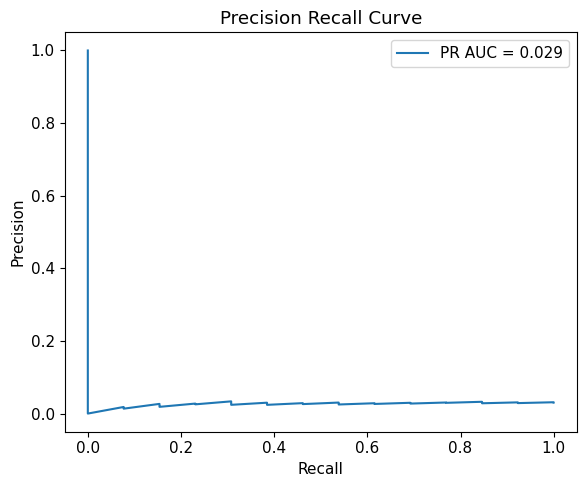

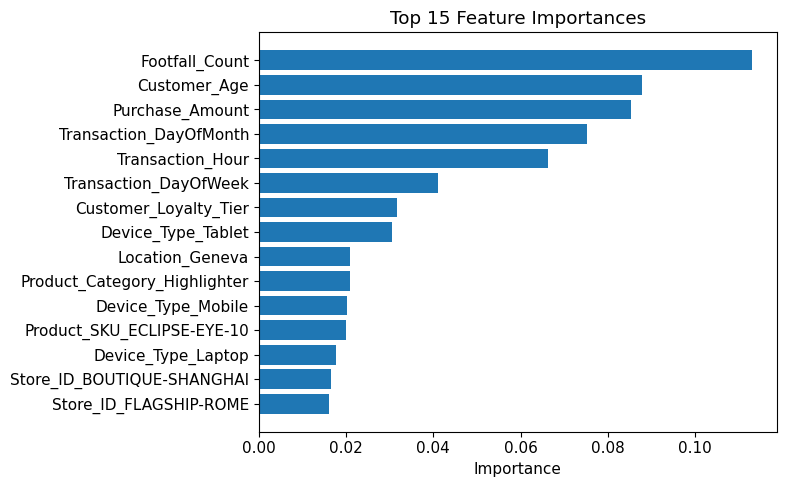


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       414
           1       0.00      0.00      0.00        13

    accuracy                           0.95       427
   macro avg       0.48      0.49      0.49       427
weighted avg       0.94      0.95      0.95       427



In [ ]:
# Retrieve the best model
best_rf = rf_search.best_estimator_

print("Tuned Random Forest Results\n")

tuned_rf_results = evaluate_model(
    best_rf,
    X_test,
    y_test,
    X_train.columns
)

In [ ]:
# Define the XGBoost parameter grid
xgb_parameters = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# Create the XGBoost model
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Perform randomized search
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_parameters,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

# Display the best parameters
print("Best XGBoost Parameters")
print(xgb_search.best_params_)

Best XGBoost Parameters
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


Tuned XGBoost Results

Accuracy : 0.7073
Precision: 0.0172
Recall   : 0.1538
F1 Score : 0.031
ROC AUC  : 0.4887
PR AUC   : 0.0318


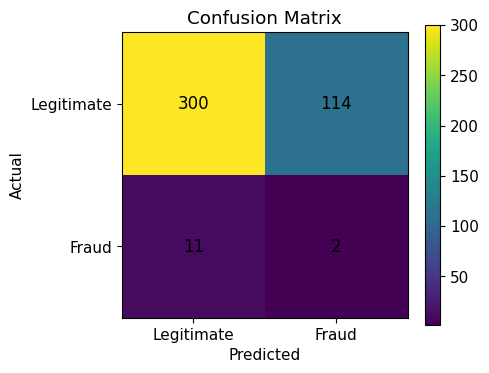

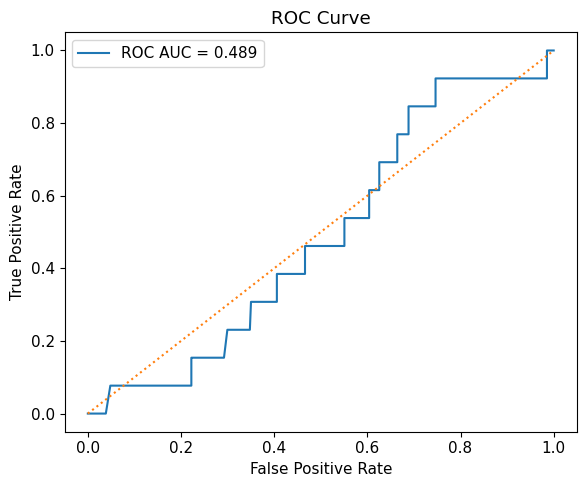

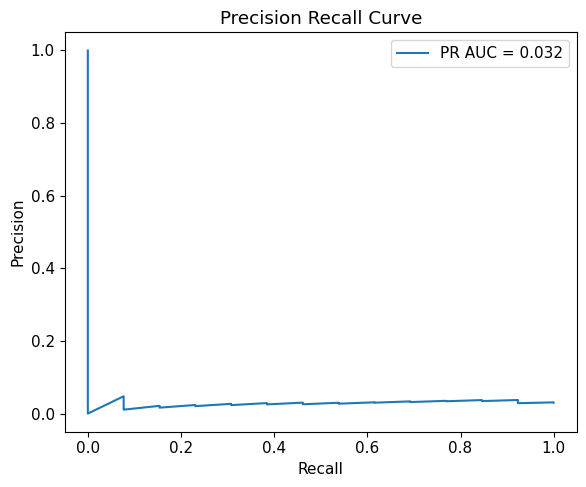

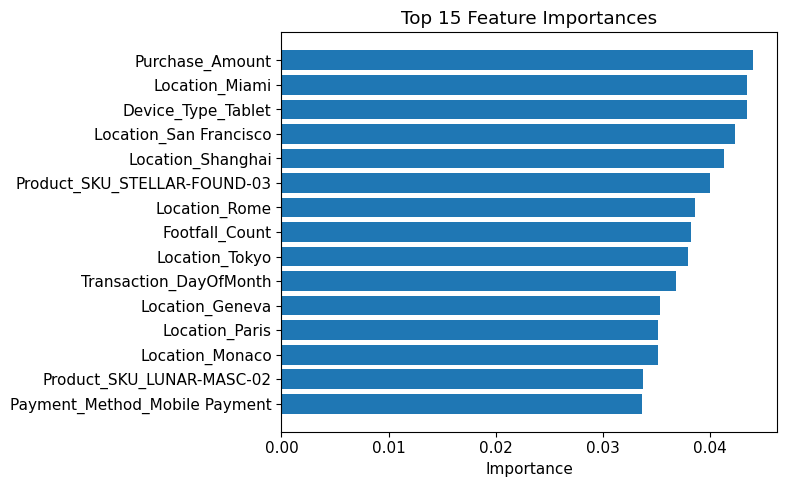


Classification Report
              precision    recall  f1-score   support

           0       0.96      0.72      0.83       414
           1       0.02      0.15      0.03        13

    accuracy                           0.71       427
   macro avg       0.49      0.44      0.43       427
weighted avg       0.94      0.71      0.80       427



In [ ]:
# Retrieve the best model
best_xgb = xgb_search.best_estimator_

print("Tuned XGBoost Results\n")

tuned_xgb_results = evaluate_model(
    best_xgb,
    X_test,
    y_test,
    X_train.columns
)

In [ ]:
# Define the LightGBM parameter grid
lgbm_parameters = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

# Create the LightGBM model
lgbm = LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=-1
)

# Perform randomized search
lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_parameters,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

# Display the best parameters
print("Best LightGBM Parameters")
print(lgbm_search.best_params_)

Best LightGBM Parameters
{'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.05}


Tuned LightGBM Results

Accuracy : 0.9532
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.4411
PR AUC   : 0.0289


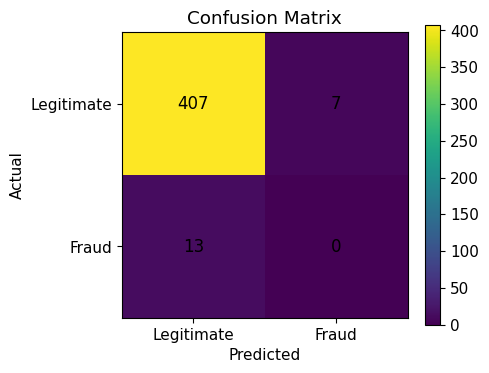

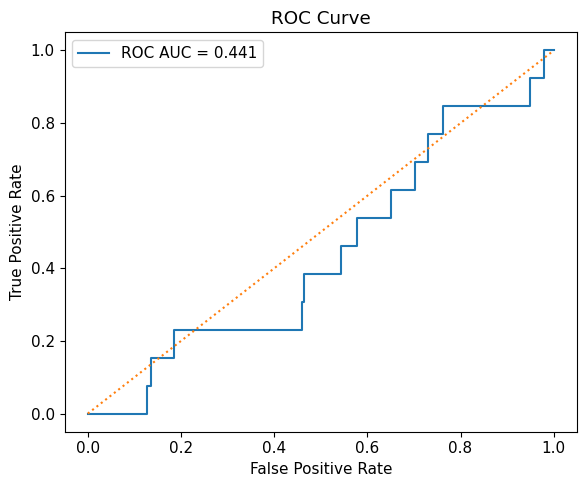

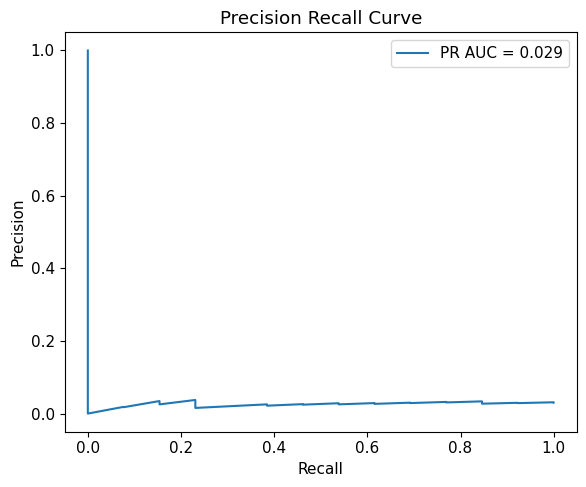

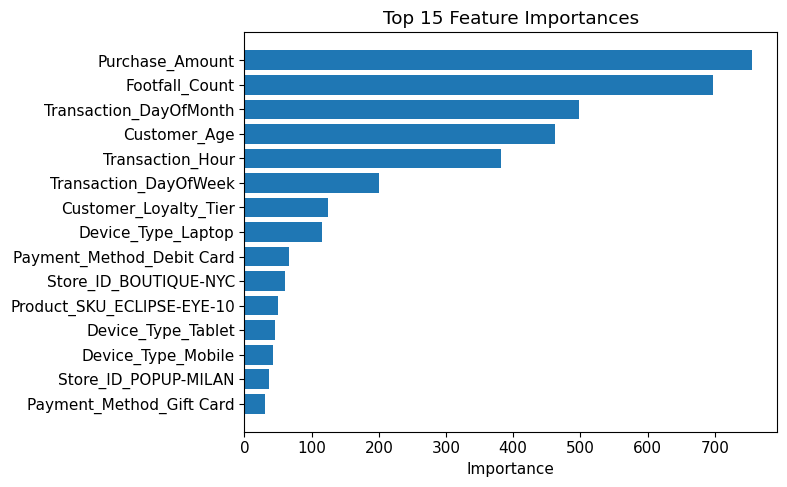


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       414
           1       0.00      0.00      0.00        13

    accuracy                           0.95       427
   macro avg       0.48      0.49      0.49       427
weighted avg       0.94      0.95      0.95       427



In [ ]:
# Retrieve the best model
best_lgbm = lgbm_search.best_estimator_

print("Tuned LightGBM Results\n")

tuned_lgbm_results = evaluate_model(
    best_lgbm,
    X_test,
    y_test,
    X_train.columns
)

In [ ]:
# Compare the performance of all models
comparison_results = pd.DataFrame(
    [
        logistic_results,
        decision_tree_results,
        cost_logistic_results,
        cost_rf_results,
        cost_xgb_results,
        cost_lgbm_results,
        tuned_rf_results,
        tuned_xgb_results,
        tuned_lgbm_results
    ],
    index=[
        "Baseline Logistic Regression",
        "Baseline Decision Tree",
        "Cost Logistic Regression",
        "Cost Random Forest",
        "Cost XGBoost",
        "Cost LightGBM",
        "Tuned Random Forest",
        "Tuned XGBoost",
        "Tuned LightGBM"
    ]
)

comparison_results = comparison_results.round(4)

display(comparison_results)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Baseline Logistic Regression,0.9696,0.0000,0.0000,0.0000,0.5587,0.0379
Baseline Decision Tree,0.9297,0.0526,0.0769,0.0625,0.5167,0.0322
Cost Logistic Regression,0.6651,0.0357,0.3846,0.0654,0.5985,0.0745
Cost Random Forest,0.9696,0.0000,0.0000,0.0000,0.5556,0.0366
Cost XGBoost,0.9508,0.0000,0.0000,0.0000,0.5020,0.0346
Cost LightGBM,0.9485,0.0000,0.0000,0.0000,0.4318,0.0279
Tuned Random Forest,0.9532,0.0000,0.0000,0.0000,0.4554,0.0291
Tuned XGBoost,0.7073,0.0172,0.1538,0.0310,0.4887,0.0318
Tuned LightGBM,0.9532,0.0000,0.0000,0.0000,0.4411,0.0289


In [ ]:
# Display the best model for each evaluation metric
best_models = pd.DataFrame({
    "Best Model": comparison_results.idxmax(),
    "Best Score": comparison_results.max().round(4)
})

display(best_models)

,Best Model,Best Score
Accuracy,Baseline Logistic Regression,0.9696
Precision,Baseline Decision Tree,0.0526
Recall,Cost Logistic Regression,0.3846
F1 Score,Cost Logistic Regression,0.0654
ROC AUC,Cost Logistic Regression,0.5985
PR AUC,Cost Logistic Regression,0.0745


In [ ]:
# Rank models by fraud detection metrics
ranking = comparison_results.sort_values(
    by=[
        "PR AUC",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    ascending=False
)

display(ranking)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Cost Logistic Regression,0.6651,0.0357,0.3846,0.0654,0.5985,0.0745
Baseline Logistic Regression,0.9696,0.0000,0.0000,0.0000,0.5587,0.0379
Cost Random Forest,0.9696,0.0000,0.0000,0.0000,0.5556,0.0366
Cost XGBoost,0.9508,0.0000,0.0000,0.0000,0.5020,0.0346
Baseline Decision Tree,0.9297,0.0526,0.0769,0.0625,0.5167,0.0322
Tuned XGBoost,0.7073,0.0172,0.1538,0.0310,0.4887,0.0318
Tuned Random Forest,0.9532,0.0000,0.0000,0.0000,0.4554,0.0291
Tuned LightGBM,0.9532,0.0000,0.0000,0.0000,0.4411,0.0289
Cost LightGBM,0.9485,0.0000,0.0000,0.0000,0.4318,0.0279


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Get out-of-fold probabilities on the TRAINING set only

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

y_train_prob_oof = cross_val_predict(
    oof_model,
    X_train_scaled,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

Threshold Search Results (on training CV folds)



,Threshold,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives,Business Cost
0,0.10,0.2620,0.0296,0.7170,0.0569,1244,15,19940
1,0.15,0.3435,0.0300,0.6415,0.0572,1101,19,20510
2,0.20,0.4103,0.0278,0.5283,0.0527,981,25,22310
3,0.25,0.4625,0.0294,0.5094,0.0556,891,26,21910
4,0.30,0.5188,0.0306,0.4717,0.0574,793,28,21930
5,0.35,0.5692,0.0329,0.4528,0.0613,706,29,21560
6,0.40,0.6120,0.0337,0.4151,0.0623,631,31,21810
7,0.45,0.6501,0.0310,0.3396,0.0569,562,35,23120
8,0.50,0.6905,0.0316,0.3019,0.0571,491,37,23410
9,0.55,0.7286,0.0341,0.2830,0.0609,425,38,23250


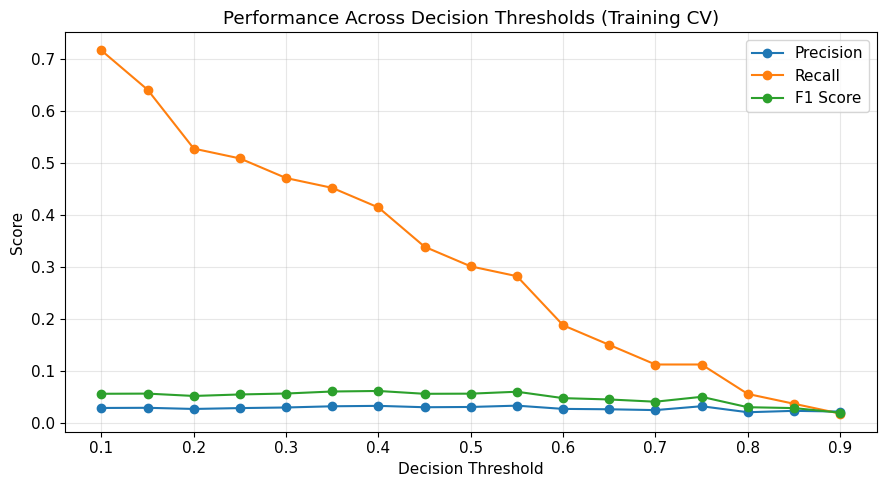

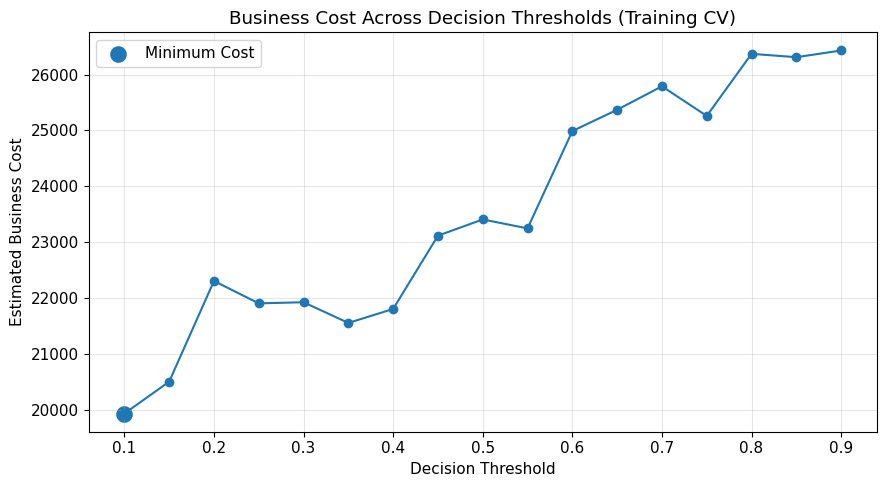

In [ ]:
# Scan thresholds against the out-of-fold TRAIN predictions,
thresholds = np.arange(0.10, 0.91, 0.05)

false_positive_cost = 10
false_negative_cost = 500

threshold_results = []

for threshold in thresholds:

    y_pred = (y_train_prob_oof >= threshold).astype(int)

    accuracy = accuracy_score(y_train, y_pred)
    precision = precision_score(y_train, y_pred, zero_division=0)
    recall = recall_score(y_train, y_pred, zero_division=0)
    f1 = f1_score(y_train, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()

    business_cost = (
        fp * false_positive_cost +
        fn * false_negative_cost
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "Business Cost": business_cost
    })

threshold_results = pd.DataFrame(threshold_results)

print("Threshold Search Results (on training CV folds)\n")
display(threshold_results.round(4))

# Plot performance across thresholds
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1 Score"], marker="o", label="F1 Score")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Performance Across Decision Thresholds (Training CV)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot business cost across thresholds
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["Threshold"], threshold_results["Business Cost"], marker="o")
best_index = threshold_results["Business Cost"].idxmin()
plt.scatter(
    threshold_results.loc[best_index, "Threshold"],
    threshold_results.loc[best_index, "Business Cost"],
    s=120,
    label="Minimum Cost"
)
plt.xlabel("Decision Threshold")
plt.ylabel("Estimated Business Cost")
plt.title("Business Cost Across Decision Thresholds (Training CV)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Lock in the threshold chosen from training-CV only.
best_row = threshold_results.loc[threshold_results["Business Cost"].idxmin()]

print("Optimal Threshold Based on Business Cost (chosen from training data)\n")
display(best_row.to_frame().T.round(4))

best_threshold = best_row["Threshold"]

Optimal Threshold Based on Business Cost (chosen from training data)



,Threshold,Accuracy,Precision,Recall,F1 Score,False Positives,False Negatives,Business Cost
0,0.1,0.262,0.0296,0.717,0.0569,1244.0,15.0,19940.0


Final Classification Report on TEST SET (threshold fixed beforehand)

              precision    recall  f1-score   support

           0       1.00      0.16      0.28       414
           1       0.04      1.00      0.07        13

    accuracy                           0.19       427
   macro avg       0.52      0.58      0.18       427
weighted avg       0.97      0.19      0.28       427



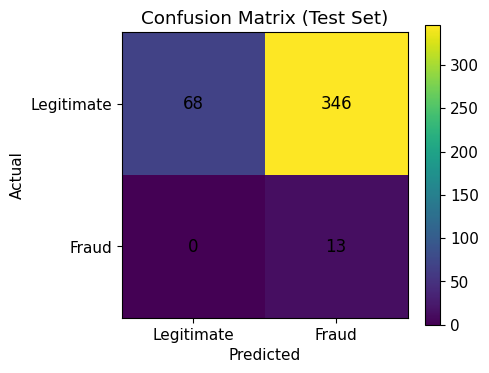

Final Estimated Business Cost (unbiased, on held-out test set): 3460


In [ ]:
# Touch the test set exactly ONCE, using the threshold

y_prob_test = cost_logistic_model.predict_proba(X_test_scaled)[:, 1]
y_pred_best = (y_prob_test >= best_threshold).astype(int)

print("Final Classification Report on TEST SET (threshold fixed beforehand)\n")
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix (Test Set)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.yticks([0, 1], ["Legitimate", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
plt.colorbar()
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
business_cost = fp * false_positive_cost + fn * false_negative_cost

print(f"Final Estimated Business Cost (unbiased, on held-out test set): {business_cost}")

In [ ]:
# Import joblib
import joblib

# Save the best performing model
joblib.dump(cost_logistic_model, "cost_sensitive_logistic_regression.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
# Save the fitted scaler
joblib.dump(scaler, "standard_scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [ ]:
# Save the final feature names in their training order
joblib.dump(
    X_train.columns.tolist(),
    "feature_names.pkl"
)

# Save the optimal decision threshold
joblib.dump(
    float(best_threshold),
    "optimal_threshold.pkl"
)

['optimal_threshold.pkl']

In [ ]:
# Load saved artefacts for verification
saved_model = joblib.load(
    "cost_sensitive_logistic_regression.pkl"
)

saved_scaler = joblib.load(
    "standard_scaler.pkl"
)

saved_features = joblib.load(
    "feature_names.pkl"
)

saved_threshold = joblib.load(
    "optimal_threshold.pkl"
)

print("Number of model features:", saved_model.n_features_in_)
print("Number of saved features:", len(saved_features))
print("Optimal threshold:", saved_threshold)

print("\nSaved Features")
print(saved_features)

Number of model features: 59
Number of saved features: 59
Optimal threshold: 0.1

Saved Features
['Customer_Age', 'Customer_Loyalty_Tier', 'Purchase_Amount', 'Footfall_Count', 'Transaction_Hour', 'Transaction_DayOfWeek', 'Transaction_DayOfMonth', 'Location_Dubai', 'Location_Geneva', 'Location_Hong Kong', 'Location_Las Vegas', 'Location_London', 'Location_Los Angeles', 'Location_Miami', 'Location_Milan', 'Location_Monaco', 'Location_Monte Carlo', 'Location_New York', 'Location_Paris', 'Location_Rome', 'Location_San Francisco', 'Location_Shanghai', 'Location_Singapore', 'Location_Sydney', 'Location_Tokyo', 'Location_Zurich', 'Store_ID_BOUTIQUE-NYC', 'Store_ID_BOUTIQUE-SHANGHAI', 'Store_ID_CONCESSION-LONDON', 'Store_ID_CONCESSION-SINGAPORE', 'Store_ID_FLAGSHIP-LA', 'Store_ID_FLAGSHIP-PARIS', 'Store_ID_FLAGSHIP-ROME', 'Store_ID_POPUP-MILAN', 'Store_ID_POPUP-TOKYO', 'Product_SKU_CELESTE-EYE-05', 'Product_SKU_COSMIC-HIGHLIGHT-06', 'Product_SKU_ECLIPSE-EYE-10', 'Product_SKU_GALAXIA-SET-08', '

In [ ]:
# Create the corrected Streamlit dashboard application
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from datetime import date, time


# Page configuration
st.set_page_config(
    page_title="Payment Card Fraud Detection",
    page_icon="💳",
    layout="wide"
)


# Load saved artefacts
model = joblib.load("cost_sensitive_logistic_regression.pkl")
scaler = joblib.load("standard_scaler.pkl")
threshold = joblib.load("optimal_threshold.pkl")


# Get exact training feature structures
model_features = list(model.feature_names_in_)
scaler_features = list(scaler.feature_names_in_)


# Application title
st.title("Payment Card Fraud Detection Dashboard")

st.write(
    "Cost-sensitive machine learning system for identifying "
    "potentially fraudulent luxury retail transactions."
)


# Sidebar information
st.sidebar.header("Model Information")

st.sidebar.write(
    "Model: Cost-Sensitive Logistic Regression"
)

st.sidebar.write(
    f"Decision Threshold: {threshold:.2f}"
)

st.sidebar.write(
    "False Positive Cost: 10"
)

st.sidebar.write(
    "False Negative Cost: 500"
)

st.sidebar.write(
    f"Model Features: {len(model_features)}"
)


# Transaction details
st.header("Transaction Details")

col1, col2, col3 = st.columns(3)


# First input column
with col1:

    customer_age = st.number_input(
        "Customer Age",
        min_value=18,
        max_value=65,
        value=35,
        step=1
    )

    loyalty_tier = st.selectbox(
        "Customer Loyalty Tier",
        [
            "Bronze",
            "Silver",
            "Gold",
            "Platinum",
            "VIP"
        ]
    )

    purchase_amount = st.number_input(
        "Purchase Amount",
        min_value=50.0,
        max_value=300.0,
        value=150.0,
        step=1.0
    )


# Second input column
with col2:

    location = st.selectbox(
        "Location",
        [
            "Dubai",
            "Geneva",
            "Hong Kong",
            "Las Vegas",
            "London",
            "Los Angeles",
            "Miami",
            "Milan",
            "Monaco",
            "Monte Carlo",
            "New York",
            "Paris",
            "Rome",
            "San Francisco",
            "Shanghai",
            "Singapore",
            "Sydney",
            "Tokyo",
            "Zurich"
        ]
    )

    payment_method = st.selectbox(
        "Payment Method",
        [
            "Credit Card",
            "Debit Card",
            "Gift Card",
            "Mobile Payment"
        ]
    )

    device_type = st.selectbox(
        "Device Type",
        [
            "Desktop",
            "Laptop",
            "Mobile",
            "Tablet"
        ]
    )


# Third input column
with col3:

    product_category = st.selectbox(
        "Product Category",
        [
            "Blush",
            "Concealer",
            "Eyeliner",
            "Eyeshadow Palette",
            "Foundation",
            "Highlighter",
            "Lipstick",
            "Mascara",
            "Serum",
            "Setting Spray"
        ]
    )

    footfall_count = st.number_input(
        "Footfall Count",
        min_value=50,
        max_value=500,
        value=250,
        step=1
    )

    transaction_date = st.date_input(
        "Transaction Date",
        value=date(2025, 7, 1),
        min_value=date(2025, 2, 1),
        max_value=date(2025, 8, 31)
    )

    transaction_time = st.time_input(
        "Transaction Time",
        value=time(12, 0)
    )


# Store and product information
st.subheader("Store and Product Information")

col4, col5 = st.columns(2)


with col4:

    store_id = st.selectbox(
        "Store ID",
        [
            "BOUTIQUE-NYC",
            "BOUTIQUE-SHANGHAI",
            "CONCESSION-LONDON",
            "CONCESSION-SINGAPORE",
            "FLAGSHIP-LA",
            "FLAGSHIP-PARIS",
            "FLAGSHIP-ROME",
            "POPUP-MILAN",
            "POPUP-TOKYO"
        ]
    )


with col5:

    product_sku = st.selectbox(
        "Product SKU",
        [
            "AURORA-LIP-01",
            "CELESTE-EYE-05",
            "COSMIC-HIGHLIGHT-06",
            "ECLIPSE-EYE-10",
            "GALAXIA-SET-08",
            "LUNAR-MASC-02",
            "NEBULA-SERUM-07",
            "ORION-CONCEAL-09",
            "SOLAR-BLUSH-04",
            "STELLAR-FOUND-03"
        ]
    )


# Function to prepare a transaction
def prepare_transaction():

    # Create all 59 model features with initial value zero
    transaction = pd.DataFrame(
        np.zeros((1, len(model_features))),
        columns=model_features
    )


    # Numerical features
    transaction.loc[
        0,
        "Customer_Age"
    ] = customer_age

    transaction.loc[
        0,
        "Purchase_Amount"
    ] = purchase_amount

    transaction.loc[
        0,
        "Footfall_Count"
    ] = footfall_count


    # Loyalty tier ordinal encoding
    loyalty_mapping = {
        "Bronze": 0,
        "Silver": 1,
        "Gold": 2,
        "Platinum": 3,
        "VIP": 4
    }

    transaction.loc[
        0,
        "Customer_Loyalty_Tier"
    ] = loyalty_mapping[loyalty_tier]


    # Temporal feature engineering
    transaction.loc[
        0,
        "Transaction_Hour"
    ] = transaction_time.hour

    transaction.loc[
        0,
        "Transaction_DayOfWeek"
    ] = transaction_date.weekday()

    transaction.loc[
        0,
        "Transaction_DayOfMonth"
    ] = transaction_date.day


    # Categorical values
    categorical_values = {
        "Location": location,
        "Store_ID": store_id,
        "Product_SKU": product_sku,
        "Product_Category": product_category,
        "Payment_Method": payment_method,
        "Device_Type": device_type
    }


    # Apply one hot encoding
    for variable, value in categorical_values.items():

        feature_name = f"{variable}_{value}"

        if feature_name in transaction.columns:

            transaction.loc[
                0,
                feature_name
            ] = 1


    return transaction


# Function to apply the saved preprocessing
def preprocess_transaction(transaction):

    # Preserve complete 59 feature structure
    processed = transaction.copy()


    # Scale only the six features used during training
    processed.loc[
        :,
        scaler_features
    ] = scaler.transform(
        processed[scaler_features]
    )


    # Enforce exact model feature order
    processed = processed.reindex(
        columns=model_features
    )


    return processed


# Prediction section
st.divider()

st.header("Fraud Risk Assessment")


if st.button(
    "Analyse Transaction",
    type="primary",
    use_container_width=True
):

    # Prepare the complete transaction
    transaction = prepare_transaction()


    # Apply training preprocessing
    transaction_processed = preprocess_transaction(
        transaction
    )


    # Generate fraud probability
    fraud_probability = model.predict_proba(
        transaction_processed
    )[0, 1]


    # Apply cost sensitive threshold
    fraud_prediction = int(
        fraud_probability >= threshold
    )


    # Display prediction metrics
    metric1, metric2, metric3 = st.columns(3)


    metric1.metric(
        "Fraud Probability",
        f"{fraud_probability * 100:.2f}%"
    )


    metric2.metric(
        "Decision Threshold",
        f"{threshold * 100:.2f}%"
    )


    if fraud_prediction == 1:

        metric3.metric(
            "Classification",
            "Potential Fraud"
        )

    else:

        metric3.metric(
            "Classification",
            "Legitimate"
        )


    st.divider()


    # Display prediction result
    if fraud_prediction == 1:

        st.error(
            "Potential fraudulent transaction detected."
        )

        st.warning(
            "The predicted fraud probability exceeds the "
            "cost-sensitive decision threshold. The transaction "
            "should be reviewed before approval."
        )

    else:

        st.success(
            "Transaction classified as legitimate."
        )


    # Risk interpretation
    st.subheader("Risk Interpretation")


    if fraud_probability >= 0.70:

        risk_level = "Very High"

    elif fraud_probability >= 0.40:

        risk_level = "High"

    elif fraud_probability >= threshold:

        risk_level = "Elevated"

    else:

        risk_level = "Low"


    st.write(
        f"Risk Level: **{risk_level}**"
    )


    # Probability visualization
    st.subheader("Prediction Probability")


    probability_data = pd.DataFrame({
        "Class": [
            "Legitimate",
            "Fraud"
        ],
        "Probability": [
            1 - fraud_probability,
            fraud_probability
        ]
    })


    st.bar_chart(
        probability_data.set_index("Class")
    )


    # Transaction summary
    st.subheader("Transaction Summary")


    summary = pd.DataFrame({
        "Attribute": [
            "Customer Age",
            "Loyalty Tier",
            "Purchase Amount",
            "Location",
            "Payment Method",
            "Device Type",
            "Product Category",
            "Store ID",
            "Product SKU",
            "Footfall Count",
            "Transaction Date",
            "Transaction Time"
        ],
        "Value": [
            customer_age,
            loyalty_tier,
            f"${purchase_amount:.2f}",
            location,
            payment_method,
            device_type,
            product_category,
            store_id,
            product_sku,
            footfall_count,
            str(transaction_date),
            str(transaction_time)
        ]
    })


    st.dataframe(
        summary,
        use_container_width=True,
        hide_index=True
    )


# Model information
st.divider()

st.header("About the Detection Model")


st.write(
    """
    The dashboard uses a cost-sensitive Logistic Regression model
    developed for payment card fraud detection. Transaction,
    customer, product, payment, device, geographic and temporal
    characteristics are transformed into the same feature structure
    used during model training.

    Numerical and temporal variables are standardised using the
    fitted training scaler, while categorical variables are represented
    using the original encoded feature structure.

    The classification threshold was selected through business-cost
    optimisation. False negatives were assigned a substantially higher
    cost than false positives because undetected fraudulent transactions
    may result in greater financial loss.
    """
)


# Research disclaimer
st.info(
    "This dashboard is a research prototype developed for academic "
    "evaluation using a synthetic payment card transaction dataset."
)
'''


# Write the corrected application
with open("app.py", "w") as file:
    file.write(app_code)


print("app.py created successfully")

app.py created successfully


In [ ]:
# Install Streamlit
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 71.7 MB/s eta 0:00:00


In [ ]:
# Check files available in the Colab environment
import os

required_files = [
    "app.py",
    "cost_sensitive_logistic_regression.pkl",
    "standard_scaler.pkl",
    "feature_names.pkl",
    "optimal_threshold.pkl"
]

for file in required_files:
    print(file, "Found" if os.path.exists(file) else "Missing")

app.py Found
cost_sensitive_logistic_regression.pkl Found
standard_scaler.pkl Found
feature_names.pkl Found
optimal_threshold.pkl Found


In [ ]:
# Install LocalTunnel
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
# Download Cloudflare tunnel client
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /content/cloudflared

# Make the tunnel client executable
!chmod +x /content/cloudflared

# Check installation
!/content/cloudflared --version

cloudflared version 2026.7.3 (built 2026-07-23-09:58 UTC)


In [ ]:
# Start the Streamlit dashboard
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [ ]:
# Start Cloudflare Quick Tunnel
import subprocess
import time
import re

cloudflare_process = subprocess.Popen(
    [
        "/content/cloudflared",
        "tunnel",
        "--url",
        "http://localhost:8501"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None

# Read output until the public URL is generated
for _ in range(60):

    line = cloudflare_process.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(
            r"https://[a-zA-Z0-9-]+\.trycloudflare\.com",
            line
        )

        if match:
            public_url = match.group(0)
            break

    time.sleep(1)

print("\nDashboard URL:")
print(public_url)

2026-07-31T07:17:29Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-31T07:17:29Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-31T07:17:32Z INF +--------------------------------------------------------------------------------------------+
2026-07-31T07:17:32Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-31T07:17:32Z INF |  https://creation-literally-untitled-role.trycloudflar

In [ ]:
# Stop previous Streamlit and tunnel processes
!pkill -f streamlit || true
!pkill -f lt || true
!pkill -f cloudflared || true

^C
^C
^C
